In [7]:
import pandas as pd
import glob
import os

In [8]:
# folder = "./raw/California"

start = "202505"
end = "202605"

files = sorted([
    f for f in glob.glob(os.path.join("CRMLSSold*.csv"))
    if start <= os.path.basename(f).replace("CRMLSSold", "").replace(".csv", "") <= end
])

dfs = []

for file in files:
    df = pd.read_csv(file)

    filename = os.path.basename(file)
    yyyymm = filename.replace("CRMLSSold", "").replace(".csv", "")

    df["date"] = pd.to_datetime(yyyymm, format="%Y%m")

    dfs.append(df)

sold_df = pd.concat(dfs, ignore_index=True)

print(sold_df.shape)
sold_df.head()

/var/folders/yg/htr3vlg56hvfr0cd4v_9cfnc0000gn/T/ipykernel_29952/1041739944.py:14: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file)
/var/folders/yg/htr3vlg56hvfr0cd4v_9cfnc0000gn/T/ipykernel_29952/1041739944.py:14: DtypeWarning: Columns (4,74) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file)


(281823, 79)


,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,...,LotSizeArea,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,date
0,PacificWest,PacificWest,NaN,NaN,NaN,NaN,NaN,NaN,551926853,joshuacho1004@gmail.com,...,16897.0,NaN,NaN,NaN,NaN,90716,NaN,16897.0,NaN,2025-05-01
1,HighDesert,HighDesert,Laminate,True,NaN,NaN,False,650000.0,542203048,JLangley@RigelCap.com,...,213915.0,NaN,False,2.0,NaN,92301,NaN,213915.0,NaN,2025-05-01
2,HighDesert,HighDesert,NaN,True,NaN,NaN,NaN,25003.0,520854275,meiwangrealestate@yahoo.com,...,100188.0,NaN,False,NaN,NaN,92301,NaN,100188.0,NaN,2025-05-01
3,OrangeCounty,OrangeCounty,NaN,True,NaN,NaN,False,6000.0,520747217,chriszoch@ochomes.org,...,3870.0,2.0,False,2.0,Capistrano Unified,92629,NaN,3870.0,NaN,2025-05-01
4,NorthSanLuisObispo,NorthSanLuisObispo,NaN,True,NaN,NaN,NaN,675000.0,502744209,kylerhamann@gmail.com,...,160.0,NaN,False,NaN,NaN,93451,0.0,6969600.0,NaN,2025-05-01


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter data
df_filtered = sold_df[
    (sold_df["PropertyType"] == "Residential") &
    (sold_df["PropertySubType"] == "SingleFamilyResidence")
].copy()

print(f"Rows after filtering: {df_filtered.shape[0]}")

# Target variables
features = ["ClosePrice", "LivingArea", "BedroomsTotal", "BathroomsTotalInteger", "LotSizeArea"]

# Descriptive statistics
print(df_filtered[features].describe())


Rows after filtering: 141997
         ClosePrice     LivingArea  BedroomsTotal  BathroomsTotalInteger  \
count  1.419970e+05  141919.000000  141997.000000          141984.000000   
mean   1.344654e+06    2048.649644       3.492581               2.632452   
std    8.084465e+06    1044.085649       0.963529               1.131934   
min    0.000000e+00       0.000000       0.000000               0.000000   
25%    6.250000e+05    1386.000000       3.000000               2.000000   
50%    8.900000e+05    1820.000000       3.000000               2.000000   
75%    1.425000e+06    2440.000000       4.000000               3.000000   
max    9.895000e+08   56500.000000      22.000000              35.000000   

        LotSizeArea  
count  1.395770e+05  
mean   1.836091e+04  
std    2.013154e+05  
min    0.000000e+00  
25%    5.413000e+03  
50%    7.100000e+03  
75%    1.000000e+04  
max    4.379087e+07  


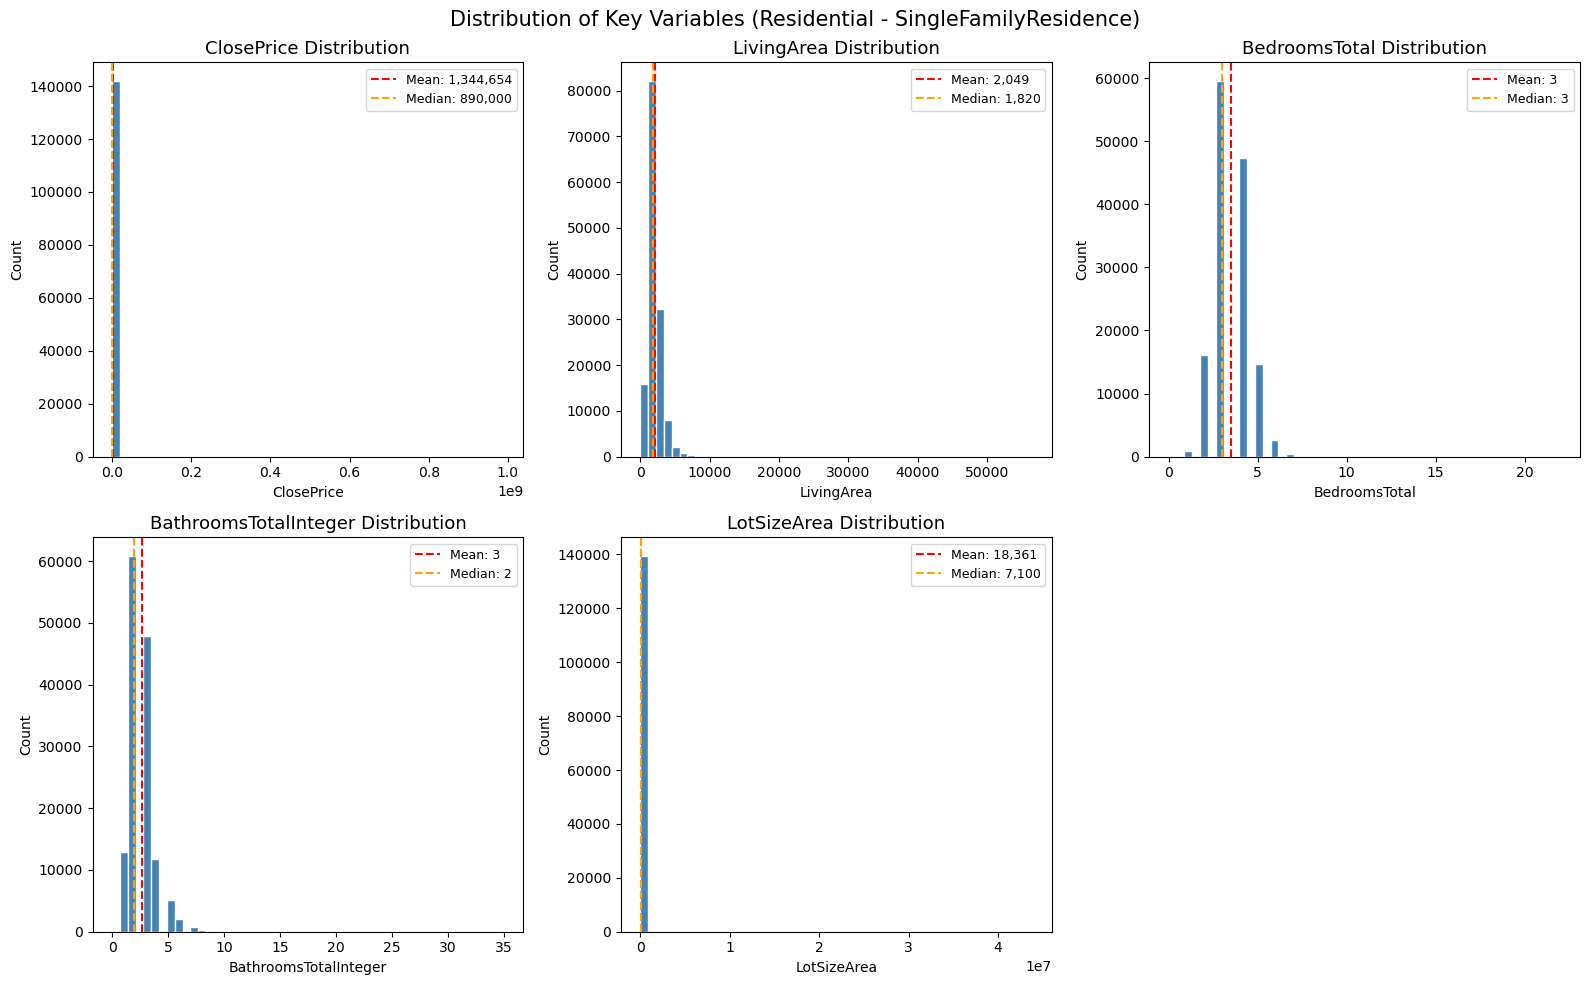

In [10]:

# Distribution plots
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(features):
    data = df_filtered[col].dropna()
    
    axes[i].hist(data, bins=50, edgecolor='white', color='steelblue')
    axes[i].set_title(f"{col} Distribution", fontsize=13)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")
    
    # Mean / Median lines
    axes[i].axvline(data.mean(), color='red', linestyle='--', label=f'Mean: {data.mean():,.0f}')
    axes[i].axvline(data.median(), color='orange', linestyle='--', label=f'Median: {data.median():,.0f}')
    axes[i].legend(fontsize=9)

# Hide the last empty subplot
axes[-1].set_visible(False)

plt.suptitle("Distribution of Key Variables (Residential - SingleFamilyResidence)", fontsize=15)
plt.tight_layout()
plt.show()


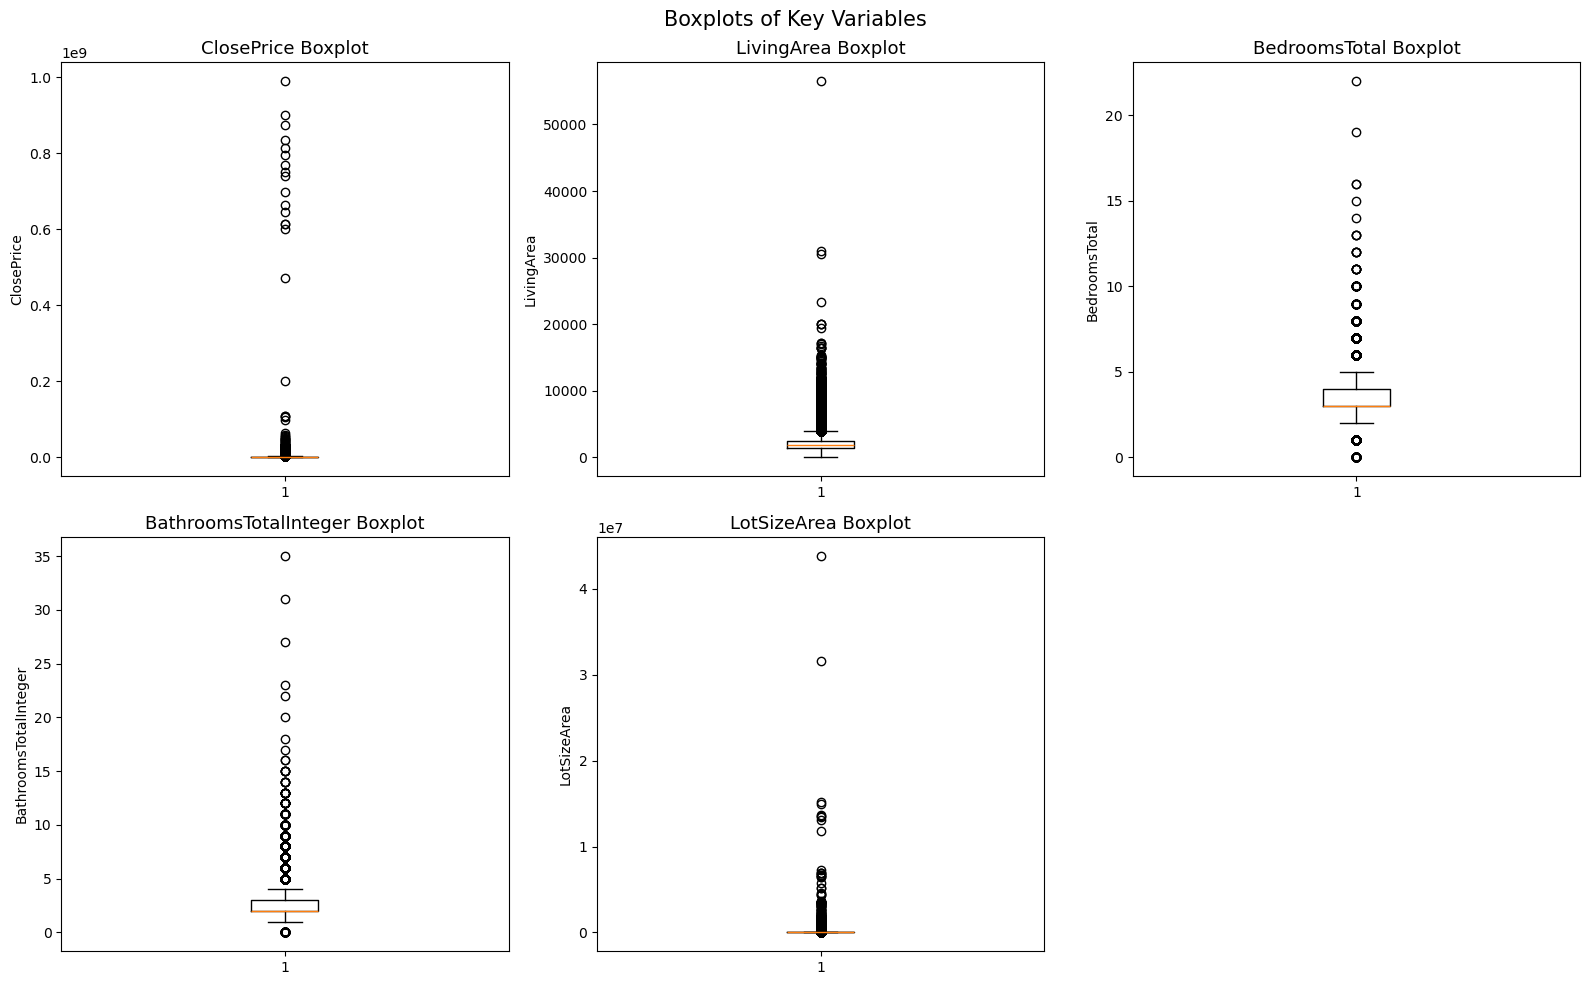

In [11]:

# Boxplots for outlier detection
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(features):
    data = df_filtered[col].dropna()
    axes[i].boxplot(data, vert=True)
    axes[i].set_title(f"{col} Boxplot", fontsize=13)
    axes[i].set_ylabel(col)

axes[-1].set_visible(False)

plt.suptitle("Boxplots of Key Variables", fontsize=15)
plt.tight_layout()
plt.show()

In [12]:
df_filtered.to_csv("merged_sales_data.csv", index=False)